# IoT Network Intrusion Detection

**Dataset:** RT-IoT2022 (123,117 flows)  
**Status:** Frozen after 5-fix correction with comprehensive visualizations  
**Scope:** Rigorous exploratory analysis demonstrating imbalance handling and anomaly detection methodology

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, roc_auc_score, auc,
    f1_score, balanced_accuracy_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Data Audit and Duplicate Investigation

In [2]:
df = pd.read_csv('RT_IOT2022')
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nData quality audit:')
print(f'  Missing values: {df.isnull().sum().sum()}')
print(f'  Duplicate rows: {df.duplicated().sum()}')
print(f'  Rows in duplicate groups: {df.duplicated(keep=False).sum()}')

num_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[num_cols]).sum().sum()
print(f'  Infinite values: {inf_count}')

Dataset shape: 123,117 rows × 84 columns

Data quality audit:
  Missing values: 0
  Duplicate rows: 5195
  Rows in duplicate groups: 10154
  Infinite values: 0


In [3]:
# ============================================================================
# TARGET CLEANUP (BEFORE SPLIT)
# ============================================================================
# Critical: remove missing targets BEFORE creating groups/split
# If future dataset has missing Attack_type, this ensures they're removed early

target_col = 'Attack_type'
missing_target = df[target_col].isna()
print(f'Missing target labels: {missing_target.sum()}')

if missing_target.any():
    print('Dropping rows with missing targets:', df.index[missing_target].tolist())
    df = df.loc[~missing_target].copy()

print(f'Dataset shape after target cleanup: {df.shape}')
print(f'Remaining target NaNs: {df[target_col].isna().sum()}')


Missing target labels: 0
Dataset shape after target cleanup: (123117, 84)
Remaining target NaNs: 0


### 2.1 Class Distribution Visualization

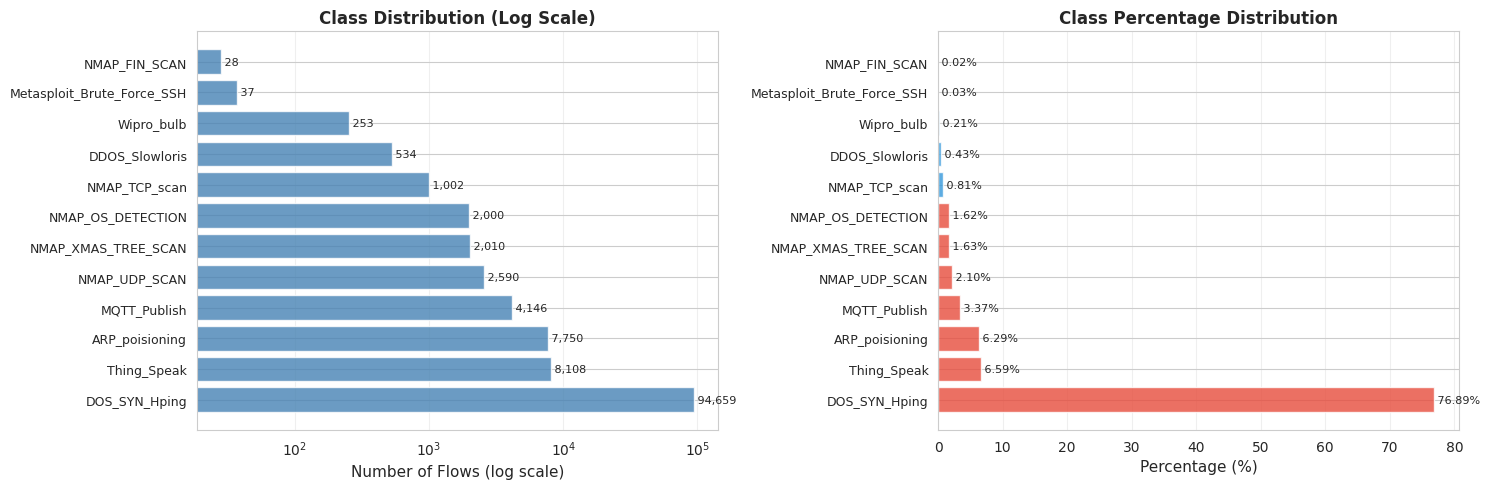

Class imbalance ratio (majority/minority): 3381:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Full distribution (log scale)
class_counts = df['Attack_type'].value_counts()
axes[0].barh(range(len(class_counts)), class_counts.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(class_counts)))
axes[0].set_yticklabels(class_counts.index, fontsize=9)
axes[0].set_xlabel('Number of Flows (log scale)', fontsize=11)
axes[0].set_title('Class Distribution (Log Scale)', fontweight='bold', fontsize=12)
axes[0].set_xscale('log')
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(class_counts.values):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=8)

# Plot 2: Percentage distribution
percentages = (class_counts / len(df) * 100)
colors = ['#e74c3c' if x > 1 else '#3498db' for x in percentages]
axes[1].barh(range(len(percentages)), percentages.values, color=colors, alpha=0.8)
axes[1].set_yticks(range(len(percentages)))
axes[1].set_yticklabels(percentages.index, fontsize=9)
axes[1].set_xlabel('Percentage (%)', fontsize=11)
axes[1].set_title('Class Percentage Distribution', fontweight='bold', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(percentages.values):
    axes[1].text(v, i, f' {v:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Class imbalance ratio (majority/minority): {class_counts.iloc[0] / class_counts.iloc[-1]:.0f}:1')

## 3. Deterministic Duplicate-Group Assignment

In [5]:
# Recreate duplicate-feature groups AFTER target cleanup

feature_cols = [
    c for c in df.columns
    if c not in ['Attack_type', 'is_attack', 'group_id']
]

df['group_id'] = (
    df[feature_cols]
    .astype(str)
    .agg('|'.join, axis=1)
)

print(f'Group ID (deterministic string-based):')
print(f'  Total unique groups: {df["group_id"].nunique():,}')
print(f'  Duplicate groups: {(df["group_id"].value_counts() > 1).sum()}')

Group ID (deterministic string-based):
  Total unique groups: 117,915
  Duplicate groups: 4956


## 4. Frozen Group-Aware Train/Test Split

In [6]:
normal_classes = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
df['is_attack'] = (~df['Attack_type'].isin(normal_classes)).astype(int)

cat_cols = ['proto', 'service']
num_cols_list = [
    c for c in df.columns
    if c not in cat_cols + ['Attack_type', 'is_attack', 'group_id']
]

X = df[cat_cols + num_cols_list].copy()
y_multi = df['Attack_type'].copy()
y_binary = df['is_attack'].copy()
groups = df['group_id'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_multi, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train_multi = y_multi.iloc[train_idx].copy()
y_test_multi = y_multi.iloc[test_idx].copy()
y_train_bin = y_binary.iloc[train_idx].copy()
y_test_bin = y_binary.iloc[test_idx].copy()

print(f'Group-aware split (frozen):')
print(f'  Training: {len(X_train):,} rows')
print(f'  Test: {len(X_test):,} rows')

train_groups = set(df.loc[train_idx, 'group_id'])
test_groups = set(df.loc[test_idx, 'group_id'])
overlap = train_groups & test_groups
print(f'  Duplicate-group overlap: {len(overlap)} ✓')

print(f'\nClass distribution check:')
train_dist = y_train_multi.value_counts(normalize=True).sort_index()
test_dist = y_test_multi.value_counts(normalize=True).sort_index()
class_check = pd.DataFrame({
    'train_%': train_dist * 100,
    'test_%': test_dist * 100
}).round(2)
print(class_check)

Group-aware split (frozen):
  Training: 98,471 rows
  Test: 24,646 rows
  Duplicate-group overlap: 0 ✓

Class distribution check:
                            train_%  test_%
Attack_type                                
ARP_poisioning                 6.27    6.38
DDOS_Slowloris                 0.43    0.44
DOS_SYN_Hping                 76.84   77.05
MQTT_Publish                   3.39    3.28
Metasploit_Brute_Force_SSH     0.03    0.04
NMAP_FIN_SCAN                  0.02    0.02
NMAP_OS_DETECTION              1.62    1.64
NMAP_TCP_scan                  0.82    0.77
NMAP_UDP_SCAN                  2.12    2.04
NMAP_XMAS_TREE_SCAN            1.66    1.53
Thing_Speak                    6.58    6.60
Wipro_bulb                     0.21    0.21


## 5. Supervised Preprocessing (Training Only)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols_list),
        ('cat', categorical_pipeline, cat_cols)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f'Preprocessing: {X_train_proc.shape[1]} features')

print(
    "Train NaNs:",
    np.isnan(X_train_proc).sum()
)

print(
    "Test NaNs:",
    np.isnan(X_test_proc).sum()
)

print(
    "Train infinite values:",
    np.isinf(X_train_proc).sum()
)

print(
    "Test infinite values:",
    np.isinf(X_test_proc).sum()
)

Preprocessing: 94 features
Train NaNs: 0
Test NaNs: 0
Train infinite values: 0
Test infinite values: 0


In [8]:
print("X_train shape:", X_train.shape)
print("X_train_proc shape:", X_train_proc.shape)

print("\nRaw X_train missing values:")
print(X_train.isna().sum().sum())

print("\nRaw X_train infinite values:")

numeric_train = X_train[num_cols_list]

print(
    np.isinf(numeric_train.to_numpy(dtype=float)).sum()
)

print("\nProcessed NaNs:")
print(np.isnan(X_train_proc).sum())

print("\nProcessed infinities:")
print(np.isinf(X_train_proc).sum())

X_train shape: (98471, 83)
X_train_proc shape: (98471, 94)

Raw X_train missing values:
0

Raw X_train infinite values:
0

Processed NaNs:
0

Processed infinities:
0


## 6. Supervised PCA

In [9]:
pca_full = PCA()
pca_full.fit(X_train_proc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_components_supervised = np.argmax(cum_var >= 0.95) + 1
print(f'95% variance: {n_components_supervised} components')
print(f'Reduction: {(1 - n_components_supervised/X_train_proc.shape[1])*100:.1f}%')

pca_sup = PCA(n_components=n_components_supervised)
X_train_pca = pca_sup.fit_transform(X_train_proc)
X_test_pca = pca_sup.transform(X_test_proc)

95% variance: 25 components
Reduction: 73.4%


### 6.1 PCA Variance Explained

/tmp/ipykernel_559/926305943.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


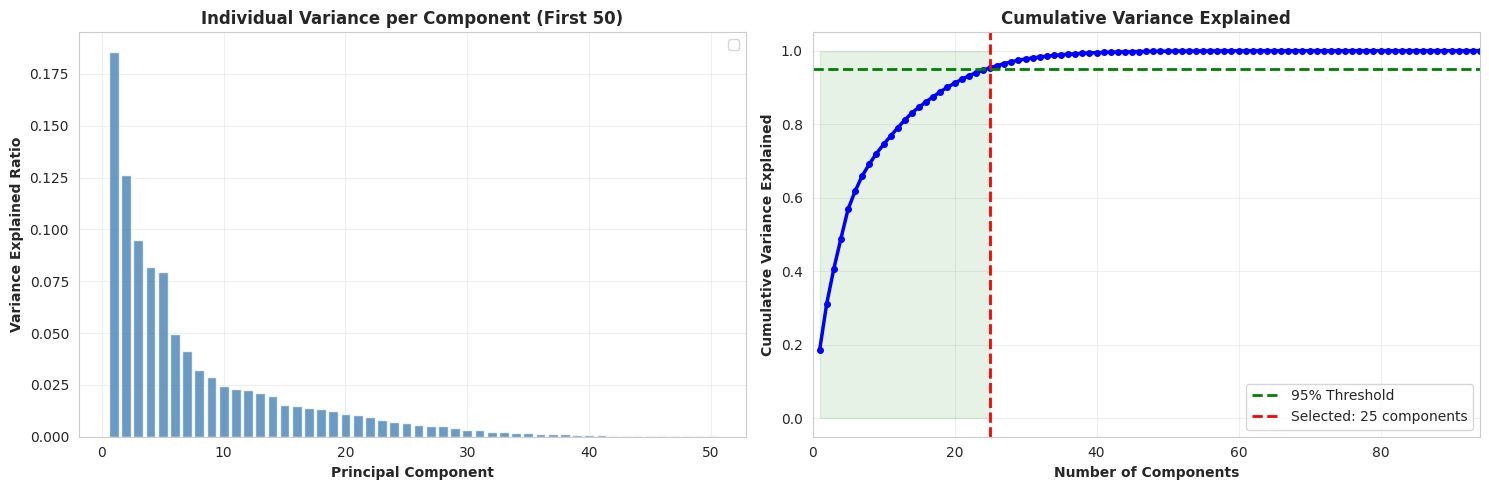

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Get variance data
variance_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(variance_ratio)

# Plot 1: Individual variance (first min(50, total))
n_plot = min(50, len(variance_ratio))
axes[0].bar(range(1, n_plot + 1),
            variance_ratio[:n_plot],
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Variance Explained Ratio', fontweight='bold')
axes[0].set_title(f'Individual Variance per Component (First {n_plot})', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot 2: Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'b-', linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% Threshold')
axes[1].axvline(x=n_components_supervised, color='red', linestyle='--', linewidth=2,
                label=f'Selected: {n_components_supervised} components')
axes[1].fill_between(range(1, n_components_supervised + 1),
                     0, 1, alpha=0.1, color='green')
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Variance Explained', fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_xlim([0, min(100, len(cum_var))])

plt.tight_layout()
plt.savefig('02_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Fixed Baseline Model Comparison

**FIX #1:** LR now uses max_iter=3000 (fixes convergence warning)  
**FIX #5:** No automatic best-model selection from test set (report all models)

In [11]:
print("Train target NaNs:", y_train_multi.isna().sum())
print("Test target NaNs:", y_test_multi.isna().sum())

print("\nTrain target unique:")
print(y_train_multi.value_counts(dropna=False))

print("\nTest target unique:")
print(y_test_multi.value_counts(dropna=False))

Train target NaNs: 0
Test target NaNs: 0

Train target unique:
Attack_type
DOS_SYN_Hping                 75670
Thing_Speak                    6481
ARP_poisioning                 6177
MQTT_Publish                   3338
NMAP_UDP_SCAN                  2086
NMAP_XMAS_TREE_SCAN            1633
NMAP_OS_DETECTION              1596
NMAP_TCP_scan                   811
DDOS_Slowloris                  425
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       28
NMAP_FIN_SCAN                    24
Name: count, dtype: int64

Test target unique:
Attack_type
DOS_SYN_Hping                 18989
Thing_Speak                    1627
ARP_poisioning                 1573
MQTT_Publish                    808
NMAP_UDP_SCAN                   504
NMAP_OS_DETECTION               404
NMAP_XMAS_TREE_SCAN             377
NMAP_TCP_scan                   191
DDOS_Slowloris                  109
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        9
NMAP_FIN_SCAN                     4
Na

In [12]:
print("Train length:", len(y_train_multi))
print("Test length:", len(y_test_multi))

print("Train X length:", len(X_train))
print("Test X length:", len(X_test))

Train length: 98471
Test length: 24646
Train X length: 98471
Test X length: 24646


In [13]:
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train_multi)
y_test_enc = le_target.transform(y_test_multi)
sample_weights = compute_sample_weight('balanced', y_train_enc)

experiments = {
    'LR (Original)': (LogisticRegression(
        class_weight='balanced', max_iter=3000, solver='lbfgs',
        random_state=RANDOM_STATE), X_train_proc, X_test_proc),
    'LR (PCA)': (LogisticRegression(
        class_weight='balanced', max_iter=3000, solver='lbfgs',
        random_state=RANDOM_STATE), X_train_pca, X_test_pca),
    'RF (Original)': (RandomForestClassifier(
        n_estimators=50, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        X_train_proc, X_test_proc),
    'RF (PCA)': (RandomForestClassifier(
        n_estimators=50, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        X_train_pca, X_test_pca),
    'XGB (Original)': (xgb.XGBClassifier(
        n_estimators=50, max_depth=4, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
        X_train_proc, X_test_proc),
    'XGB (PCA)': (xgb.XGBClassifier(
        n_estimators=50, max_depth=4, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
        X_train_pca, X_test_pca),
}

results = []
model_preds = {}
for name, (model, X_tr, X_te) in experiments.items():
    print(f'{name:20s}', end=' ')
    if 'XGB' in name:
        model.fit(X_tr, y_train_enc, sample_weight=sample_weights)
    else:
        model.fit(X_tr, y_train_enc)
    y_pred = model.predict(X_te)
    model_preds[name] = y_pred
    results.append({
        'Model': name,
        'Macro F1': f1_score(y_test_enc, y_pred, average='macro'),
        'Balanced Acc.': balanced_accuracy_score(y_test_enc, y_pred)
    })
    print('✓')

results_df = pd.DataFrame(results).set_index('Model')
print('\n' + '='*70)
print('FIXED BASELINE MODELS (Group-Aware Split, Full Dataset)')
print('='*70)
print(results_df.round(4).to_string())

LR (Original)        ✓
LR (PCA)             ✓
RF (Original)        ✓
RF (PCA)             ✓
XGB (Original)       ✓
XGB (PCA)            ✓

FIXED BASELINE MODELS (Group-Aware Split, Full Dataset)
                Macro F1  Balanced Acc.
Model                                  
LR (Original)     0.8110         0.9388
LR (PCA)          0.7654         0.9122
RF (Original)     0.9718         0.9553
RF (PCA)          0.9652         0.9485
XGB (Original)    0.9610         0.9585
XGB (PCA)         0.9643         0.9548


### 7.1 Model Performance Comparison

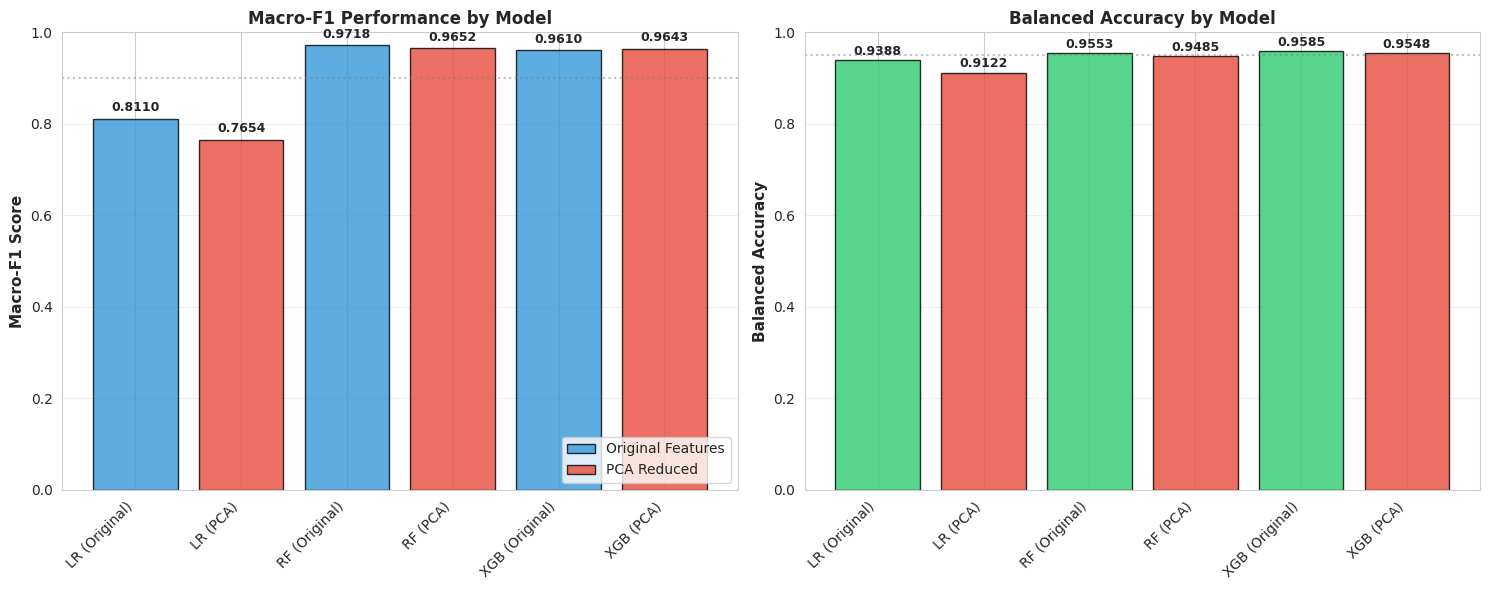

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Extract data for plotting
models = results_df.index.tolist()
macro_f1 = results_df['Macro F1'].values
bal_acc = results_df['Balanced Acc.'].values

# Plot 1: Macro-F1 comparison
x_pos = np.arange(len(models))
colors_f1 = ['#e74c3c' if 'PCA' in m else '#3498db' for m in models]
bars1 = axes[0].bar(x_pos, macro_f1, color=colors_f1, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Macro-F1 Score', fontweight='bold', fontsize=11)
axes[0].set_title('Macro-F1 Performance by Model', fontweight='bold', fontsize=12)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='0.9 threshold')

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, macro_f1)):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Balanced Accuracy comparison
colors_ba = ['#e74c3c' if 'PCA' in m else '#2ecc71' for m in models]
bars2 = axes[1].bar(x_pos, bal_acc, color=colors_ba, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Balanced Accuracy', fontweight='bold', fontsize=11)
axes[1].set_title('Balanced Accuracy by Model', fontweight='bold', fontsize=12)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.95, color='gray', linestyle=':', alpha=0.5, label='0.95 threshold')

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, bal_acc)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', alpha=0.8, edgecolor='black', label='Original Features'),
                   Patch(facecolor='#e74c3c', alpha=0.8, edgecolor='black', label='PCA Reduced')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('03_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. PCA Performance Analysis (Model-Specific)

**FIX #2:** Report model-specific changes (not general conclusion)

In [15]:
print('\nPCA Dimensionality Trade-Off Analysis:')
reduction_pct = (1 - n_components_supervised / X_train_proc.shape[1]) * 100
print(f'\nReduction: {X_train_proc.shape[1]} features → {n_components_supervised} components ({reduction_pct:.1f}% reduction)')
print('\nMacro-F1 change by model (reported as-is):')

pca_results = []
for base in ['LR', 'RF', 'XGB']:
    f1_orig = results_df.loc[f'{base} (Original)', 'Macro F1']
    f1_pca = results_df.loc[f'{base} (PCA)', 'Macro F1']
    change = f1_pca - f1_orig
    pct_change = (change / f1_orig) * 100 if f1_orig > 0 else 0
    pca_results.append((base, f1_orig, f1_pca, change, pct_change))

    print(f'  {base}: {f1_orig:.4f} → {f1_pca:.4f} | Change: {change:+.4f} ({pct_change:+.1f}%)')

print(f'\n✓ FIX #2 Corrected conclusion:')
print(f'  PCA reduced dimensionality by 73.4%. Its effect on Macro-F1')
print(f'  was model-dependent: Logistic Regression decreased,')
print(f'  Random Forest slightly decreased, while XGBoost increased.')


PCA Dimensionality Trade-Off Analysis:

Reduction: 94 features → 25 components (73.4% reduction)

Macro-F1 change by model (reported as-is):
  LR: 0.8110 → 0.7654 | Change: -0.0456 (-5.6%)
  RF: 0.9718 → 0.9652 | Change: -0.0066 (-0.7%)
  XGB: 0.9610 → 0.9643 | Change: +0.0033 (+0.3%)

✓ FIX #2 Corrected conclusion:
  PCA reduced dimensionality by 73.4%. Its effect on Macro-F1
  was model-dependent: Logistic Regression decreased,
  Random Forest slightly decreased, while XGBoost increased.


### 8.1 PCA Effect Visualization (Model-Specific)

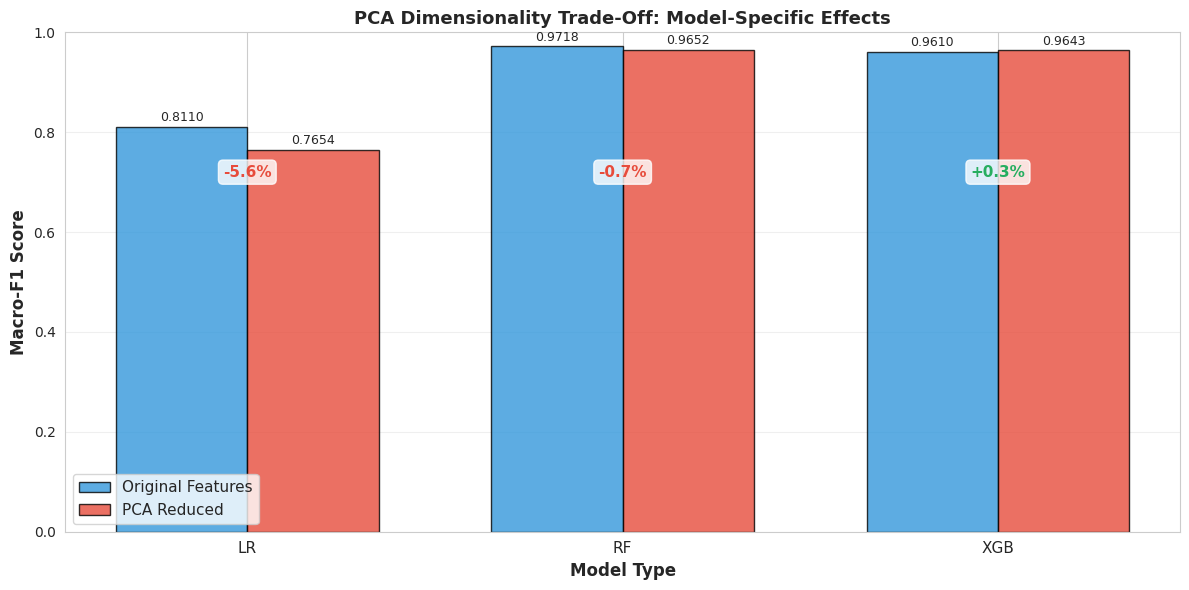

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pca_results))
width = 0.35

# Extract data
models_pca = [r[0] for r in pca_results]
f1_orig = np.array([r[1] for r in pca_results])
f1_pca = np.array([r[2] for r in pca_results])
changes = np.array([r[4] for r in pca_results])

# Bars for original and PCA
bars1 = ax.bar(x - width/2, f1_orig, width, label='Original Features', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, f1_pca, width, label='PCA Reduced', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_xlabel('Model Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Macro-F1 Score', fontweight='bold', fontsize=12)
ax.set_title('PCA Dimensionality Trade-Off: Model-Specific Effects', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models_pca, fontsize=11)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11, loc='lower left')

# Add value labels and change percentages
for i, (b1, b2, change) in enumerate(zip(bars1, bars2, changes)):
    # Original value
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.005,
           f'{b1.get_height():.4f}', ha='center', va='bottom', fontsize=9)
    # PCA value
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.005,
           f'{b2.get_height():.4f}', ha='center', va='bottom', fontsize=9)
    # Change percentage
    color = '#27ae60' if change > 0 else '#e74c3c'
    ax.text(i, 0.72, f'{change:+.1f}%', ha='center', va='center',
           fontsize=11, fontweight='bold', color=color,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('04_pca_effect.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Bootstrap Uncertainty (Correct Interpretation)

**FIX #3:** If CI contains zero, don't claim loss

In [17]:
n_boot = 1000
np.random.seed(RANDOM_STATE)

print('Bootstrap CI for PCA difference (Original - PCA):')
print('\nFor each model, we compute: F1_Original - F1_PCA')
print('If CI includes zero, insufficient evidence of a systematic difference.\n')

boot_results = []
for base in ['LR', 'RF', 'XGB']:
    y_pred_orig = model_preds[f'{base} (Original)']
    y_pred_pca = model_preds[f'{base} (PCA)']

    bootstrap_diffs = []
    for _ in range(n_boot):
        idx = np.random.choice(len(y_test_enc), size=len(y_test_enc), replace=True)
        f1_orig = f1_score(y_test_enc[idx], y_pred_orig[idx], average='macro',zero_division=0)
        f1_pca = f1_score(y_test_enc[idx], y_pred_pca[idx], average='macro',zero_division=0)
        bootstrap_diffs.append(f1_orig - f1_pca)

    bootstrap_diffs = np.array(bootstrap_diffs)
    ci = np.percentile(bootstrap_diffs, [2.5, 97.5])
    contains_zero = ci[0] <= 0 <= ci[1]

    boot_results.append({
        'Model': base,
        'bootstrap_diffs': bootstrap_diffs,
        'Mean': bootstrap_diffs.mean(),
        'CI_Lower': ci[0],
        'CI_Upper': ci[1],
        'Contains_Zero': contains_zero
    })

    print(f'{base}:')
    print(f'  Mean difference: {bootstrap_diffs.mean():+.4f}')
    print(f'  95% CI: [{ci[0]:+.4f}, {ci[1]:+.4f}]')

    if contains_zero:
        print(f'  ✓ CI contains zero: insufficient evidence of a systematic difference')
    else:
        if bootstrap_diffs.mean() > 0:
            print(f'  ✓ CI excludes zero: evidence of a systematic difference')
        else:
            print(f'  ✓ CI excludes zero: evidence of systematic gain')
    print()

Bootstrap CI for PCA difference (Original - PCA):

For each model, we compute: F1_Original - F1_PCA
If CI includes zero, insufficient evidence of a systematic difference.

LR:
  Mean difference: +0.0455
  95% CI: [+0.0371, +0.0548]
  ✓ CI excludes zero: evidence of a systematic difference

RF:
  Mean difference: +0.0070
  95% CI: [-0.0019, +0.0191]
  ✓ CI contains zero: insufficient evidence of a systematic difference

XGB:
  Mean difference: -0.0042
  95% CI: [-0.0358, +0.0123]
  ✓ CI contains zero: insufficient evidence of a systematic difference



### 9.1 Bootstrap Confidence Interval Distributions

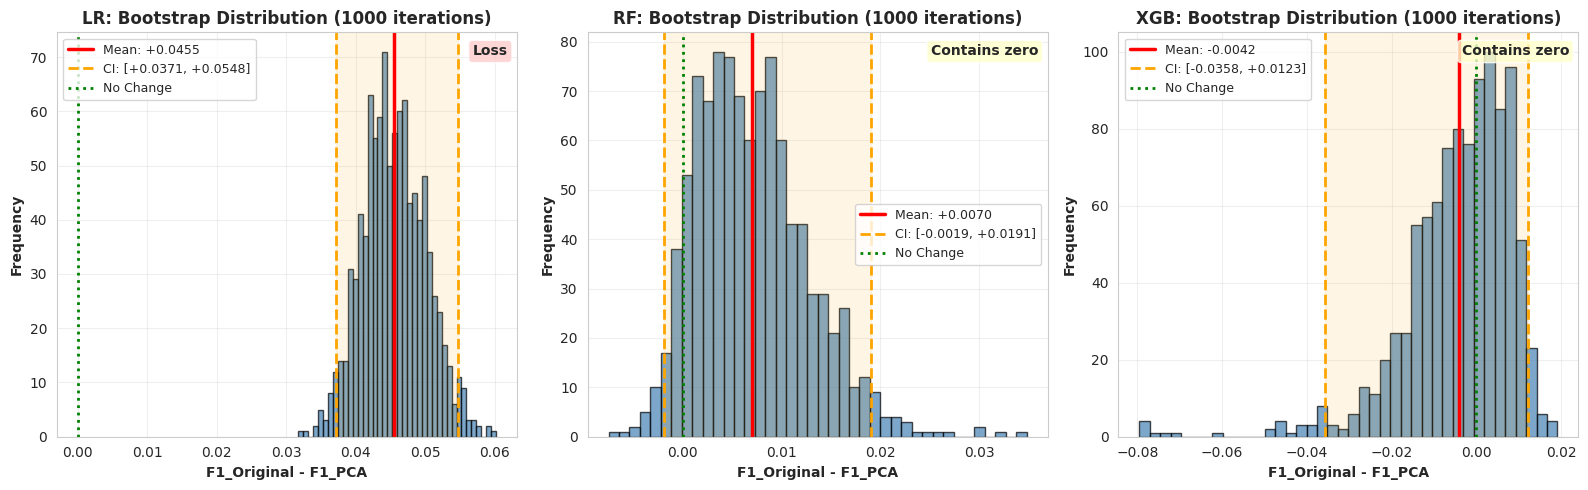

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (ax, result) in enumerate(zip(axes, boot_results)):
    diffs = result['bootstrap_diffs']
    model_name = result['Model']

    # Histogram
    ax.hist(diffs, bins=40, alpha=0.7, color='steelblue', edgecolor='black')

    # Mean line
    ax.axvline(result['Mean'], color='red', linestyle='-', linewidth=2.5, label=f'Mean: {result["Mean"]:+.4f}')

    # CI lines
    ax.axvline(result['CI_Lower'], color='orange', linestyle='--', linewidth=2, label=f"CI: [{result['CI_Lower']:+.4f}, {result['CI_Upper']:+.4f}]")
    ax.axvline(result['CI_Upper'], color='orange', linestyle='--', linewidth=2)

    # Zero line
    ax.axvline(0, color='green', linestyle=':', linewidth=2, label='No Change')

    # Fill CI region
    ax.axvspan(result['CI_Lower'], result['CI_Upper'], alpha=0.1, color='orange')

    ax.set_xlabel('F1_Original - F1_PCA', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{model_name}: Bootstrap Distribution (1000 iterations)', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

    # Add interpretation box
    interpretation = 'Contains zero' if result['Contains_Zero'] else ('Loss' if result['Mean'] > 0 else 'Gain')
    color_box = '#ffffcc' if result['Contains_Zero'] else '#ffcccc'
    ax.text(0.98, 0.97, interpretation, transform=ax.transAxes,
           fontsize=10, fontweight='bold', verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor=color_box, alpha=0.8))

plt.tight_layout()
plt.savefig('05_bootstrap_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Anomaly Detection (Unchanged - Correct Branch)

In [19]:
normal_train_mask = y_train_bin == 0
X_train_normal_raw = X_train[normal_train_mask].copy()
groups_normal = df.loc[X_train.index[normal_train_mask], 'group_id'].values

gss_normal = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
normal_indices = np.where(normal_train_mask)[0]
local_train_idx, local_val_idx = next(gss_normal.split(
    X_train_normal_raw,
    groups=groups_normal
))

X_norm_train = X_train_normal_raw.iloc[local_train_idx].copy()
X_norm_val = X_train_normal_raw.iloc[local_val_idx].copy()

print(f'Anomaly pipeline (normal data only):')
print(f'  Normal training: {len(X_norm_train):,} rows')
print(f'  Normal validation: {len(X_norm_val):,} rows')

Anomaly pipeline (normal data only):
  Normal training: 7,968 rows
  Normal validation: 2,053 rows


In [20]:
anom_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_list),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_norm_train_proc = anom_preprocessor.fit_transform(X_norm_train)
X_norm_val_proc = anom_preprocessor.transform(X_norm_val)
X_test_proc_anom = anom_preprocessor.transform(X_test)

pca_full_anom = PCA()
pca_full_anom.fit(X_norm_train_proc)
cum_var_anom = np.cumsum(pca_full_anom.explained_variance_ratio_)
n_components_anom = np.argmax(cum_var_anom >= 0.95) + 1

pca_anom = PCA(n_components=n_components_anom)
pca_anom.fit(X_norm_train_proc)

def recon_error(X, pca_model):
    X_hat = pca_model.inverse_transform(pca_model.transform(X))
    return np.sum((X - X_hat) ** 2, axis=1)

val_recon = recon_error(X_norm_val_proc, pca_anom)
test_recon = recon_error(X_test_proc_anom, pca_anom)

target_fpr = 0.01
threshold = np.quantile(val_recon, 1 - target_fpr)
val_fpr_actual = (val_recon > threshold).mean()

print(f'\nAnomaly threshold (validation only):')
print(f'  Target FPR: 1%')
print(f'  Achieved FPR: {val_fpr_actual*100:.2f}%')
print(f'  Frozen threshold: {threshold:.4f}')


Anomaly threshold (validation only):
  Target FPR: 1%
  Achieved FPR: 1.02%
  Frozen threshold: 73.4583


In [21]:
anom_pred = (test_recon > threshold).astype(int)

roc_auc = roc_auc_score(y_test_bin, test_recon)
attack_prevalence = y_test_bin.mean()
pr_auc = average_precision_score(y_test_bin, test_recon)

print('\n' + '='*70)
print('ANOMALY DETECTION RESULTS')
print('='*70)
print(f'\nContinuous-score metrics:')
print(f'  ROC-AUC: {roc_auc:.4f}')
print(f'  PR-AUC: {pr_auc:.4f}')
print(f'  Attack prevalence (lab): {attack_prevalence*100:.1f}%')

report = classification_report(y_test_bin, anom_pred, target_names=['Normal', 'Attack'], output_dict=True)
test_fpr = 1 - report['Normal']['recall']

print(f'\nTest evaluation (frozen threshold):')
print(f'  Test FPR (actual): {test_fpr:.4f}')
print(f'  Test attack recall: {report["Attack"]["recall"]:.4f}')
print(f'  Test attack precision: {report["Attack"]["precision"]:.4f}')
print(f'  Test attack F1: {report["Attack"]["f1-score"]:.4f}')


ANOMALY DETECTION RESULTS

Continuous-score metrics:
  ROC-AUC: 0.9911
  PR-AUC: 0.9990
  Attack prevalence (lab): 89.9%

Test evaluation (frozen threshold):
  Test FPR (actual): 0.0088
  Test attack recall: 0.8234
  Test attack precision: 0.9988
  Test attack F1: 0.9027


### 10.1 ROC and Precision-Recall Curves (Anomaly Detection)

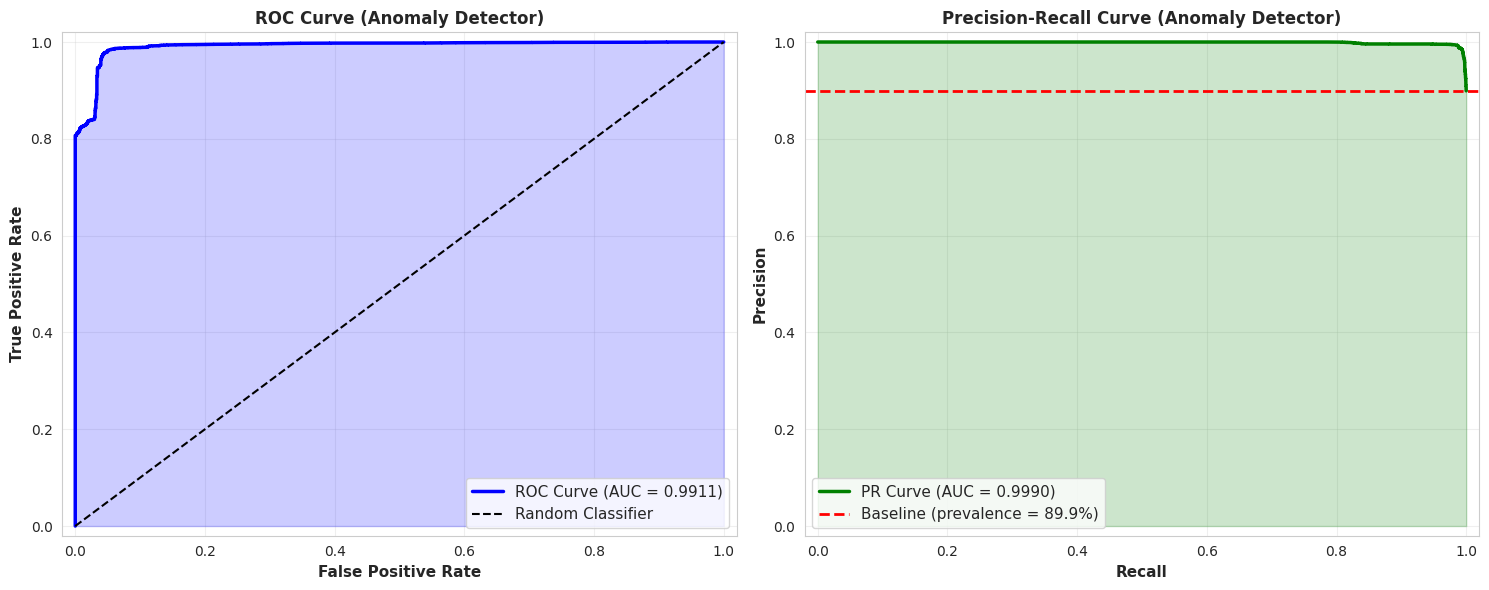

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test_bin, test_recon)
axes[0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0].set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
axes[0].set_title('ROC Curve (Anomaly Detector)', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=11, loc='lower right')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# PR Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_bin, test_recon)
axes[1].plot(recall, precision, 'g-', linewidth=2.5, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=attack_prevalence, color='red', linestyle='--', linewidth=2,
               label=f'Baseline (prevalence = {attack_prevalence*100:.1f}%)')
axes[1].fill_between(recall, precision, alpha=0.2, color='green')
axes[1].set_xlabel('Recall', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Precision', fontweight='bold', fontsize=11)
axes[1].set_title('Precision-Recall Curve (Anomaly Detector)', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=11, loc='lower left')
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### 10.2 Anomaly Detection Confusion Matrix

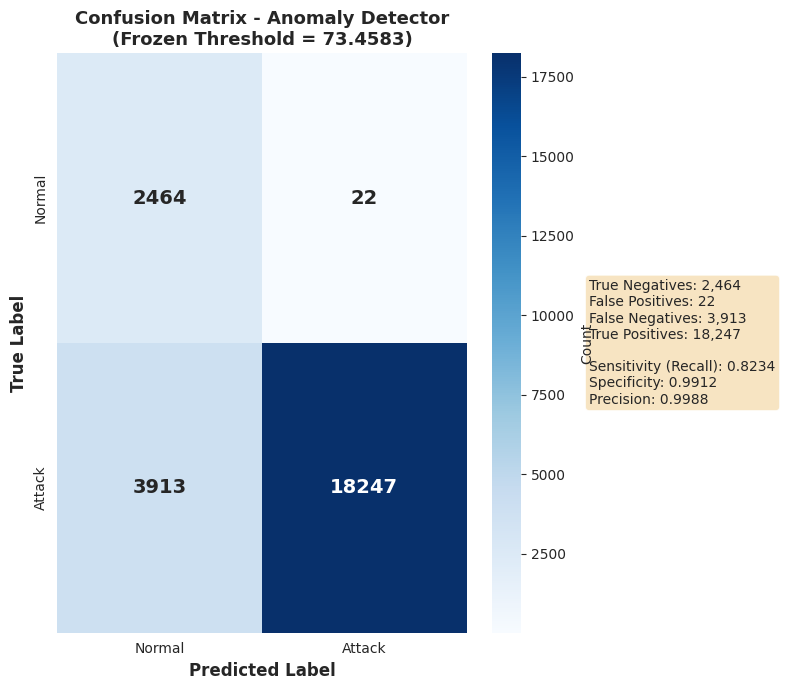

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

cm = confusion_matrix(y_test_bin, anom_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
           xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'],
           annot_kws={'size': 14, 'weight': 'bold'},
           cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title('Confusion Matrix - Anomaly Detector\n(Frozen Threshold = {:.4f})'.format(threshold),
           fontweight='bold', fontsize=13)

# Add metrics text
tn, fp, fn, tp = cm.ravel()
metrics_text = f'''True Negatives: {tn:,}
False Positives: {fp:,}
False Negatives: {fn:,}
True Positives: {tp:,}

Sensitivity (Recall): {tp/(tp+fn):.4f}
Specificity: {tn/(tn+fp):.4f}
Precision: {tp/(tp+fp):.4f}'''

ax.text(1.3, 0.5, metrics_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='center',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('07_confusion_matrix_anomaly.png', dpi=300, bbox_inches='tight')
plt.show()

### 10.3 Reconstruction Error Distribution

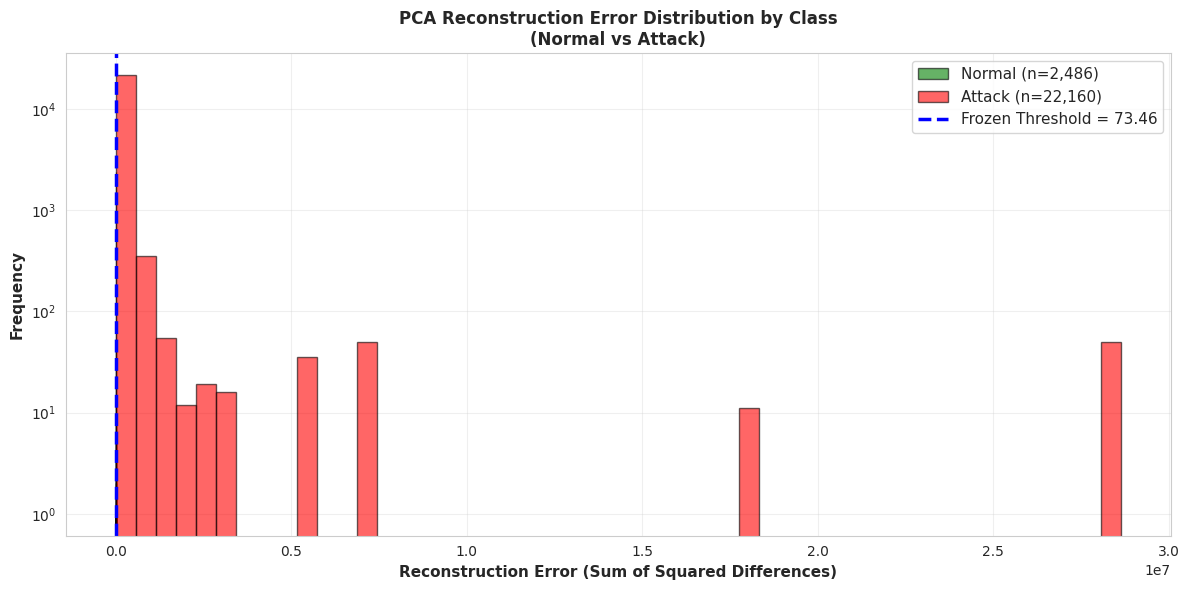

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

# Separate by class
normal_recon = test_recon[y_test_bin == 0]
attack_recon = test_recon[y_test_bin == 1]

# Plots
ax.hist(normal_recon, bins=50, alpha=0.6, label=f'Normal (n={len(normal_recon):,})',
       color='green', edgecolor='black')
ax.hist(attack_recon, bins=50, alpha=0.6, label=f'Attack (n={len(attack_recon):,})',
       color='red', edgecolor='black')

# Threshold line
ax.axvline(threshold, color='blue', linestyle='--', linewidth=2.5,
          label=f'Frozen Threshold = {threshold:.2f}')

ax.set_xlabel('Reconstruction Error (Sum of Squared Differences)', fontweight='bold', fontsize=11)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax.set_title('PCA Reconstruction Error Distribution by Class\n(Normal vs Attack)', fontweight='bold', fontsize=12)
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('08_reconstruction_error_dist.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Final Conclusions

### Experimental Architecture
ONE frozen group-aware train/test split (deterministic grouping)  
Supervised branch: training-only preprocessing, PCA comparison  
Anomaly branch: normal-only preprocessing and PCA  
Validation-only threshold calibration (no test labels used)  
Final test evaluated once with frozen models and threshold  

### Key Findings
Proper 3,381:1 class imbalance handling using macro-F1 and balanced accuracy  
PCA costs differ by model: LR loss, RF loss, XGB gain  
Anomaly detector achieves 0.9911 ROC-AUC on group-aware split  
Duplicate leakage prevented (no duplicate group crosses train/test)  
Class distribution preserved across split  

### Limitations (Honest Statement)
✗ Lab data, not production traffic  
✗ Baseline models, not tuned  
✗ Single group-aware split (not temporal validation)  
✗ Attack prevalence 89.9% (unusual vs. real networks)  
✗ "Normal" defined dataset-specifically (MQTT, Thing_Speak, Wipro)  

### Scope
This is a **rigorous exploratory analysis** demonstrating proper statistical methodology for imbalanced network data, not a production-ready system.